# Assignment: Numpy and Matplotlib
### The goal of this assignment is to gain comfort creating, visualizating, and computing with numpy array. 
### By the end of the assignment, you should feel comfortable:

## 1.) Creating and Manipulating Arrays

In [1]:
import pandas as pd
import os
import numpy as np
from matplotlib import pyplot as plt

### 1.1. Create two 2D arrays representing coordinates x, y on the cartesian plan
##### Both should cover the range (-2, 2) and have 100 points in each direction

In [2]:
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
xx, yy = np.meshgrid(x, y)

### 1.2. Visualize each 2D array using pcolormesh
##### Use the correct coordiantes for the x and y axes.

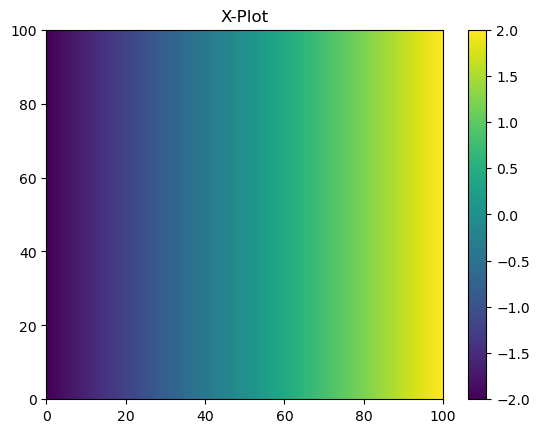

In [3]:
plt.pcolormesh(xx);
plt.title('X-Plot')
plt.colorbar()

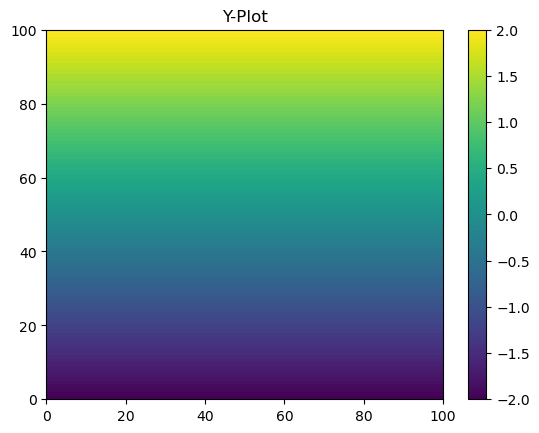

In [4]:
plt.pcolormesh(yy);
plt.title('Y-Plot')
plt.colorbar()

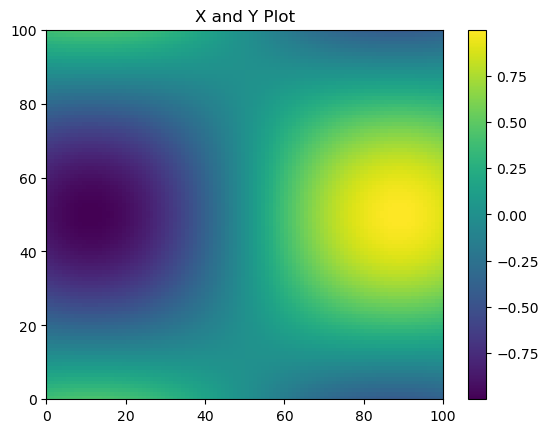

In [5]:
f = np.sin(xx)*np.cos(yy)
plt.title('X and Y Plot')
plt.pcolormesh(f);
plt.colorbar()

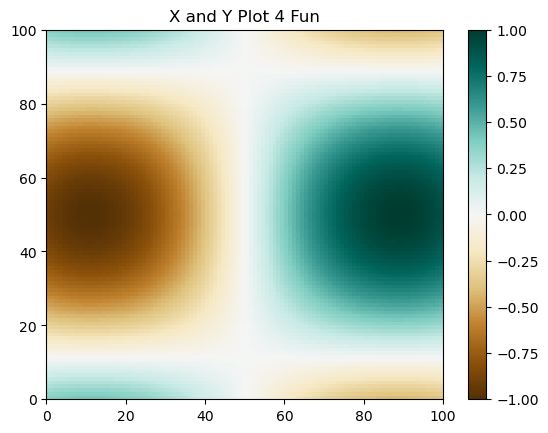

In [6]:
plt.pcolormesh(f,cmap='BrBG',vmin=-1, vmax=1) 
plt.title('X and Y Plot 4 Fun')
plt.colorbar()

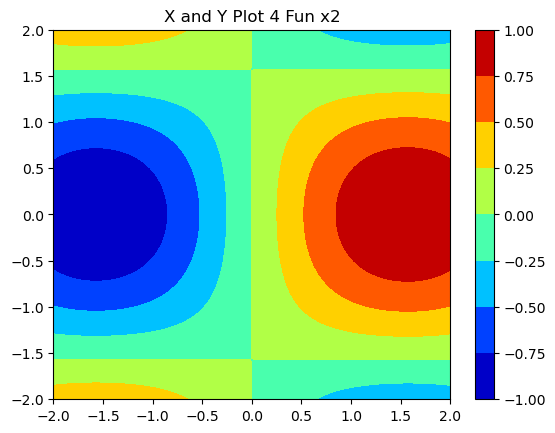

In [7]:
plt.contourf(xx,yy,f,cmap='jet')
plt.title('X and Y Plot 4 Fun x2')
plt.colorbar()

### 1.3 From your cartesian coordinates, create polar coordinates r and φ
##### Refer to the wikipedia page for the conversion formula. You will need to use numpy’s arctan2 function. Read its documentation.

In [8]:
r = np.sqrt(x**2 + y**2)
phi = np.arctan2(y,x)
r, phi = np.meshgrid(x, y)

### 1.4. Visualize r and φ on the 2D x/y plane using pcolormesh


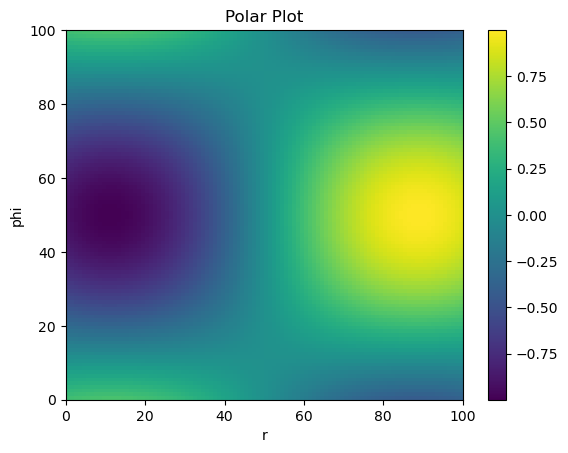

In [9]:
polar = np.sin(r)*np.cos(phi)
plt.title('Polar Plot')
plt.xlabel('r')
plt.ylabel('phi')
plt.pcolormesh(polar);
plt.colorbar() ####ask about x/y plane

### 1.5 Calculate the quantity _equation_ 
##### And plot it on the x/y$ plane

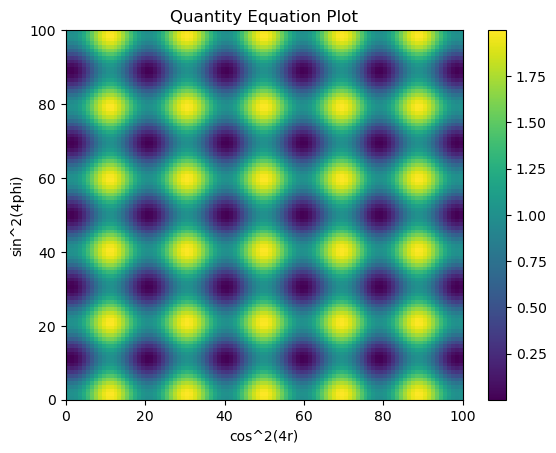

In [10]:
R2 = (np.cos(4*r)**2)
phi2 = (np.sin(4*phi)**2)
eq = R2 + phi2
plt.pcolormesh(eq);
plt.title('Quantity Equation Plot')
plt.xlabel('cos^2(4r)')
plt.ylabel('sin^2(4phi)')
plt.colorbar()

## Part 2: Analyze ARGO Data
##### In this problem, we use real data from ocean profiling floats. ARGO floats are autonomous robotic instruments that collect Temperature, Salinity, 
##### and Pressure data from the ocean. ARGO floats collect one “profile” (a set of messurements at different depths or “levels”).
##### Each profile has a single latitude, longitude, and date associated with it, in addition to many different levels.
##### Let’s start by using pooch to download the data files we need for this exercise. The following code will give you a list of .npy files that you can open in the next step.

In [11]:
import pooch
url = 'https://www.ldeo.columbia.edu/~danielmw/float_data.zip'
files = pooch.retrieve(url, processor=pooch.Unzip(), known_hash='2a703c720302c682f1662181d329c9f22f9f10e1539dc2d6082160a469165009')
files

['/home/nc3225/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/date.npy',
 '/home/nc3225/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/T.npy',
 '/home/nc3225/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/S.npy',
 '/home/nc3225/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/P.npy',
 '/home/nc3225/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/levels.npy',
 '/home/nc3225/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lon.npy',
 '/home/nc3225/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lat.npy']

### 2.1 Load each data file as a numpy array.
##### You can use whatever names you want for your arrays, but I recommend

##### T: temperature

##### S: salinity

##### P: pressure

##### date: date

##### lat: latitude

##### lon: longitude

##### level: depth level

##### Note: you have to actually look at the file name (the items in files) to know which files corresponds to which variable.

In [12]:
T = np.load('/home/nc3225/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/T.npy')
S = np.load('/home/nc3225/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/S.npy')
P = np.load('/home/nc3225/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/P.npy')
date = np.load('/home/nc3225/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/date.npy')
lat = np.load('/home/nc3225/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lat.npy')
lon = np.load('/home/nc3225/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lon.npy')
level = np.load('/home/nc3225/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/levels.npy')

### 2.2 Examine the shapes of T, S and P compared to lon, lat, date and level. How do you think they are related?
##### Based on the shapes, which dimensions do you think are shared among the arrays?

In [13]:
T.shape, S.shape, P.shape, date.shape, lat.shape, lon.shape, level.shape

((78, 75), (78, 75), (78, 75), (75,), (75,), (75,), (78,))

##### T, S, and P are 2D arrays 
##### lat, lon, and level are 1D arrays and they are related because they all represent one row that is associated with T,S and P

### 2.3 Make a plot for each column of data in T, S and P (three plots).
##### The vertical scale should be the levels data. Each plot should have a line for each column of data. It will look messy.

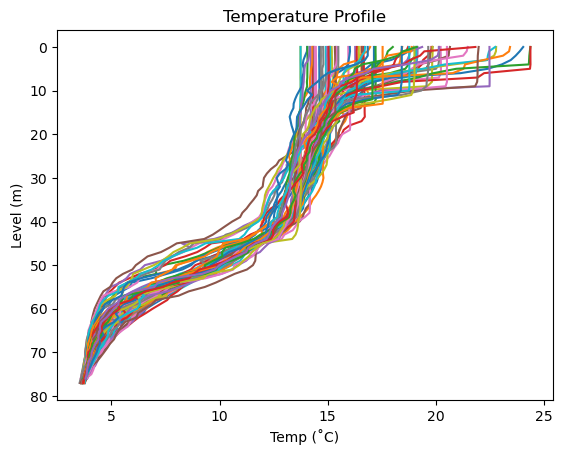

In [14]:
plt.plot(T,level)
plt.gca().invert_yaxis()
plt.title('Temperature Profile')
plt.xlabel('Temp (˚C)')
plt.ylabel('Level (m)')
plt.show()

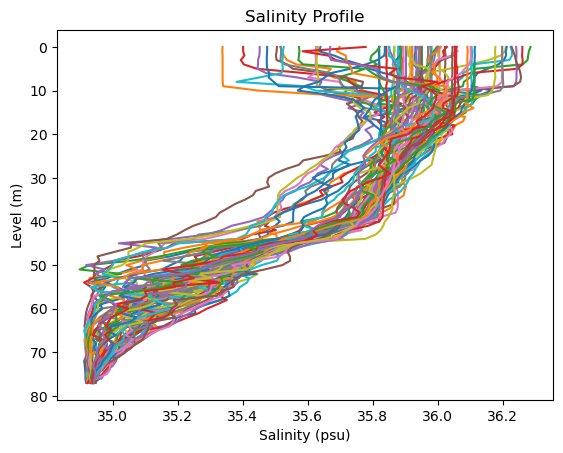

In [15]:
plt.plot(S,level)
plt.gca().invert_yaxis()
plt.title('Salinity Profile')
plt.xlabel('Salinity (psu)')
plt.ylabel('Level (m)')
plt.show()

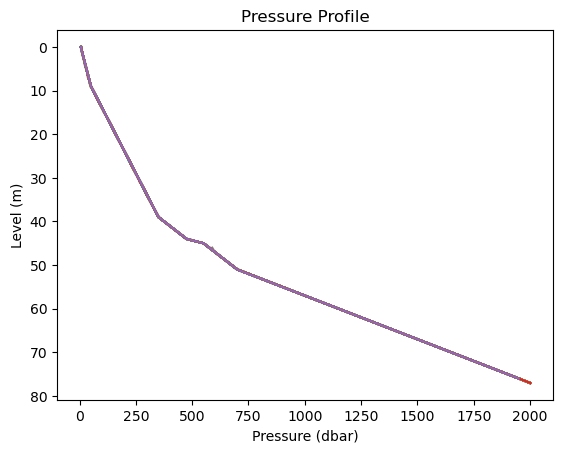

In [16]:
plt.plot(P,level)
plt.gca().invert_yaxis()
plt.title('Pressure Profile')
plt.xlabel('Pressure (dbar)')
plt.ylabel('Level (m)')
plt.show()

### 2.4 Compute the mean and standard deviation of each of T, S and P at each depth in level.

In [17]:
Tmean = T.mean(axis = 1)
Tsd = T.std(axis = 1)
Smean = S.mean(axis = 1)
Ssd = S.std(axis = 1)
Pmean = P.mean(axis = 1)
Psd = P.std(axis = 1)

### 2.5 Now make three similar plot, but show only the mean T, S and P at each depth. Show error bars on each plot using the standard deviations.

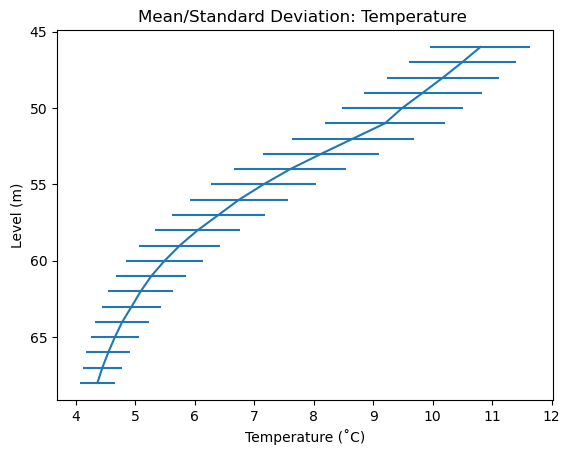

In [18]:
plt.errorbar(x=Tmean, y=level, xerr=Tsd)
plt.gca().invert_yaxis()

plt.title('Mean/Standard Deviation: Temperature ')
plt.xlabel('Temperature (˚C)')
plt.ylabel('Level (m)')

plt.show()

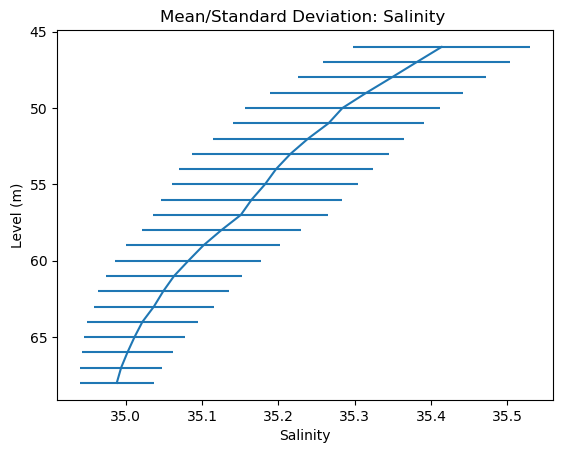

In [19]:
plt.errorbar(x=Smean, y=level, xerr=Ssd)
plt.gca().invert_yaxis()

plt.title('Mean/Standard Deviation: Salinity ')
plt.xlabel('Salinity')
plt.ylabel('Level (m)')

plt.show()

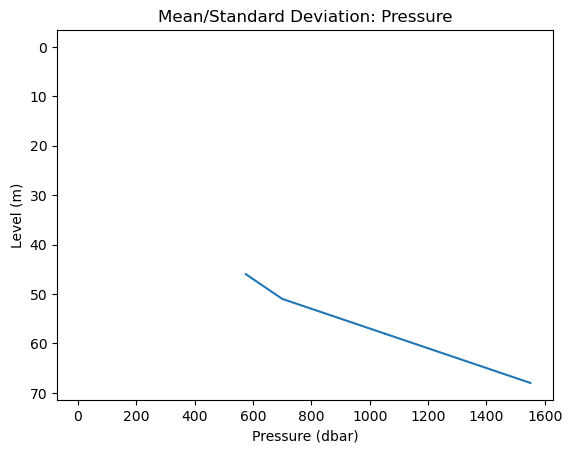

In [20]:
plt.errorbar(x=Pmean, y=level, xerr=Psd)
plt.gca().invert_yaxis()

plt.title('Mean/Standard Deviation: Pressure')
plt.xlabel('Pressure (dbar)')
plt.ylabel('Level (m)')

plt.show()

### 2.6 Account For Missing Data
##### The profiles contain many missing values. These are indicated by the special “Not a Number” value, or np.nan.

##### When you take the mean or standard deviation of data with NaNs in it, the entire result becomes NaN. 
##### Instead, if you use the special functions np.nanmean and np.nanstd, you tell NumPy to ignore the NaNs.

##### Recalculate the means and standard deviations as in the previous sections using these functions and plot the results.

In [21]:
Tmeann = np.nanmean(T, axis = 1)
Tsdd = np.nanstd(T, axis = 1)

Smeann = np.nanmean(S, axis = 1)
Ssdd =  np.nanstd(S, axis = 1)

Pmeann = np.nanmean(P, axis = 1)
Psdd =  np.nanstd(P, axis = 1)

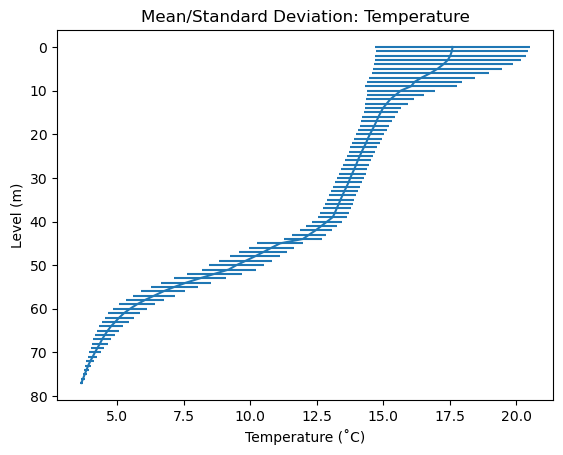

In [22]:
plt.errorbar(x=Tmeann, y=level, xerr=Tsdd)
plt.gca().invert_yaxis()

plt.title('Mean/Standard Deviation: Temperature')
plt.xlabel('Temperature (˚C)')
plt.ylabel('Level (m)')

plt.show()

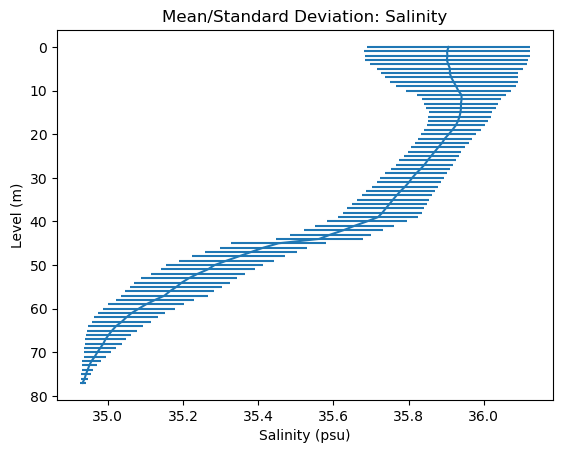

In [23]:
plt.errorbar(x=Smeann, y=level, xerr=Ssdd)
plt.gca().invert_yaxis()

plt.title('Mean/Standard Deviation: Salinity')
plt.xlabel('Salinity (psu)')
plt.ylabel('Level (m)')

plt.show()

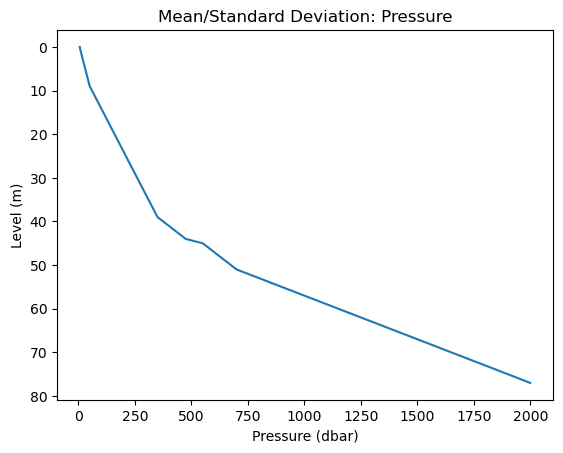

In [24]:
plt.errorbar(x=Pmeann, y=level, xerr=Psdd)
plt.gca().invert_yaxis()

plt.title('Mean/Standard Deviation: Pressure')
plt.xlabel('Pressure (dbar)')
plt.ylabel('Level (m)')

plt.show()

### 2.7 Create a scatter plot of the lon, lat positions of the ARGO float.
##### Use the plt.scatter function.

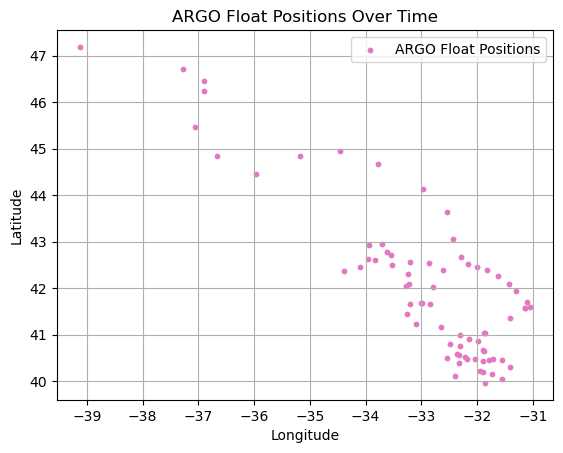

In [25]:
plt.scatter(x=lon, y=lat, c='#e377c2', s=10, label='ARGO Float Positions')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('ARGO Float Positions Over Time')
plt.legend()
plt.grid(which='major')
plt.show()